In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
tf.config.set_visible_devices(tf.config.list_physical_devices('GPU')[1], 'GPU')

import hmc_2hl as hmc

In [3]:
d = 200
alpha = 2.75
gamma_1 = 0.5
gamma_2 = 0.5

Delta = 0.2
vlaw = 'gaussd'
k1 = int(gamma_1 * d)
k2 = int(gamma_2 * d)

sig_1 = lambda x: tf.nn.tanh(2*x) / 0.797032
sig_2 = lambda x: tf.nn.tanh(2*x) / 0.797032

params = {
    'step_size': 0.01,
    'num_leapfrog_steps': 10,
    'num_adaptation_steps': 1000,
}

ntest = 10000
Xtest = tf.random.normal((d, ntest), dtype=tf.float32)


I0000 00:00:1763042246.855002 3265580 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 14242 MB memory:  -> device: 1, name: NVIDIA RTX A4000, pci bus id: 0000:65:00.0, compute capability: 8.6


In [4]:
W10, W20, v, X, Y = hmc.data_generate(d, alpha, gamma_1, gamma_2, sig_1, sig_2, Delta, vlaw)
W1s_info, W2s_info = hmc.hmc(params, W10, W20, v, X, Y, Delta, sig_1, sig_2)
test_info = hmc.test_error(W1s_info, W2s_info, W10, W20, v, sig_1, sig_2, Xtest)

In [5]:
qw1s = [tf.reduce_mean(W1*W10) for W1 in W1s_info]
qw2s = [tf.reduce_mean(W2*W20) for W2 in W2s_info]

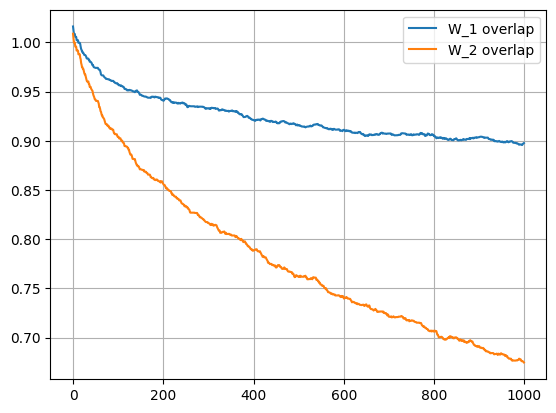

In [6]:
plt.plot(qw1s, label='W_1 overlap')
plt.plot(qw2s, label='W_2 overlap')
plt.legend()
plt.grid()
plt.show()

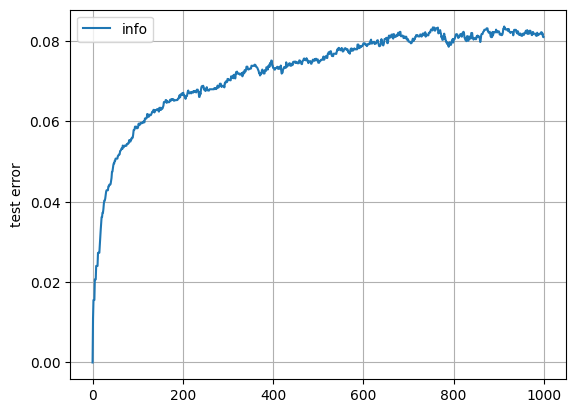

In [7]:
plt.plot(test_info, label='info')
plt.ylabel('test error')
plt.legend()
plt.grid()
plt.show()

## Continue the HMC

In [8]:
W1s_info_next, W2s_info_next = hmc.hmc(params, W1s_info[-1], W2s_info[-1], v, X, Y, Delta, sig_1, sig_2)
qw1s_next = [tf.reduce_mean(W1*W10) for W1 in W1s_info_next]
qw2s_next = [tf.reduce_mean(W2*W20) for W2 in W2s_info_next]

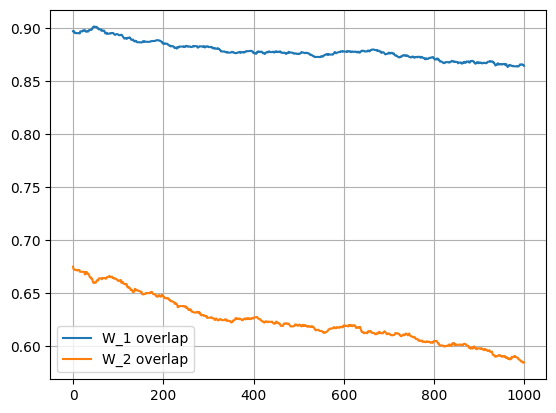

In [9]:
plt.plot(qw1s_next, label='W_1 overlap')
plt.plot(qw2s_next, label='W_2 overlap')
plt.legend()
plt.grid()
plt.show()